# Breast Cancer Wisconsin Diagnostic Dataset 
- ➡️This is a classic dataset for training and benchmarking machine learning algorithms.
- ➡️ Biopsy features for classification of 569 malignant (cancer) and benign (not cancer) breast masses.
- ➡️ Features were computationally extracted from digital images of fine needle aspirate biopsy slides. Features correspond to properties of cell nuclei, such as size, shape and regularity. The mean, standard error, and worst value of each of 10 nuclear parameters is reported for a total of 30 features.
 
Available: https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset?resource=download 

### Details
- y. The outcomes. A factor with two levels denoting whether a mass is malignant ("M") or benign ("B").
- x. The predictors. A matrix with the mean, standard error and worst value of each of 10 nuclear measurements on the slide, for 30 total features per biopsy:
    - radius. Nucleus radius (mean of distances from center to points on perimeter).
    - texture. Nucleus texture (standard deviation of grayscale values).
    - perimeter. Nucleus perimeter.
    - area. Nucleus area.
    - smoothness. Nucleus smoothness (local variation in radius lengths).
    -  compactness. Nucleus compactness (perimeter^2/area - 1).
    - concavity, Nucleus concavity (severity of concave portions of the contour).
    - concave_pts. Number of concave portions of the nucleus contour.
    - symmetry. Nucleus symmetry.
    - fractal_dim. Nucleus fractal dimension ("coastline approximation" -1).

|Column	| Description|
|---------|-------------|
|x.radius_mean	|Mean radius of the tumor cells|
|x.radius_mean	|Mean radius of the tumor cells
|x.texture_mean	|Mean texture of the tumor cells
|x.perimeter_mean	|Mean perimeter of the tumor cells
|x.area_mean	|Mean area of the tumor cells
|x.smoothness_mean	|Mean smoothness of the tumor cells
|x.compactness_mean	|Mean compactness of the tumor cells
|x.concavity_mean	|Mean concavity of the tumor cells
|x.concave_points_mean	|Mean number of concave portions of the contour of the tumor cells
|x.symmetry_mean	|Mean symmetry of the tumor cells
|x.fractal_dimension_mean	|Mean "coastline approximation" of the tumor cells
|x.radius_se	|Standard error of the radius of the tumor cells
|x.texture_se	|Standard error of the texture of the tumor cells
|x.perimeter_se	|Standard error of the perimeter of the tumor cells
|x.area_se	|Standard error of the area of the tumor cells
|x.smoothness_se	|Standard error of the smoothness of the tumor cells
|x.compactness_se	|Standard error of the compactness of the tumor cells
|x.concavity_se	|Standard error of the concavity of the tumor cells
|x.concave_points_se	|Standard error of the number of concave portions of the contour of the tumor cells
|x.symmetry_se	|Standard error of the symmetry of the tumor cells
|x.fractal_dimension_se	|Standard error of the "coastline approximation" of the tumor cells
|x.radius_worst	|Worst (largest) radius of the tumor cells
|x.texture_worst	|Worst (most severe) texture of the tumor cells
|x.perimeter_worst	|Worst (largest) perimeter of the tumor cells
|x.area_worst	|Worst (largest) area of the tumor cells
|x.smoothness_worst	|Worst (most severe) smoothness of the tumor cells
|x.compactness_worst	|Worst (most severe) compactness of the tumor cells
|x.concavity_worst	|Worst (most severe) concavity of the tumor cells
|x.concave_points_worst	|Worst (most severe) number of concave portions of the contour of the tumor cells
|x.symmetry_worst	|Worst (most severe) symmetry of the tumor cells
|x.fractal_dimension_worst	|Worst (most severe) "coastline approximation" of the tumor cells
|y	target

In [99]:
#libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns      
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Model 1: Baseline KNN (All 30 features)

### 1.1. Load the data

I created this Baseline Model using the original 30 columns of the dataset to establish a starting point. In Machine Learning, you need to see how the algorithm performs when you give it absolutely all the raw information. This is the only way I can measure if the data cleaning and Feature Selection I do later actually improve the model. If I don't test with the 30 variables first, I have no way to prove the mathematical value of my work in the next phases.

In [79]:
df = pd.read_csv('brca_clean.csv')

### 1.2. Define X (all 30 deatures) and y (target)

In [80]:
X_baseline = df.drop(columns=['y'])
y_baseline = df['y']

### 1.3. Train/Test Split (80% train and 20% test)

In [81]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_baseline, y_baseline, test_size=0.2, random_state=0)

### 1.4. Initialize and train the Baseline KNN Model

In [82]:
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_b, y_train_b)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 1.5. Make predictions and evaluate 

In [83]:
#Accuracy
y_pred_b = knn_baseline.predict(X_test_b)
baseline_accuracy = accuracy_score(y_test_b, y_pred_b)

In [84]:
print(f"--- BASELINE MODEL V1 (All 30 Features) ---")
print(f"Accuracy: {baseline_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_b))

--- BASELINE MODEL V1 (All 30 Features) ---
Accuracy: 0.9386

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        71
           1       1.00      0.84      0.91        43

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



In [85]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_baseline = confusion_matrix(y_test_b, y_pred_b)
print(cm_baseline)

[[71  0]
 [ 7 36]]


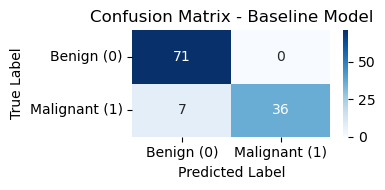

In [86]:
fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Baseline Model')
plt.tight_layout()

1. Analyzing My First Model Results (The Raw Baseline)
"This is the very first model of my project, and I trained it using all 30 original columns without any modifications or scaling. The overall Accuracy came out to 84.21%. While an 84% might look okay at first glance for a normal project, we have to look deeper because we are dealing with medical data."

2. The Danger in the Confusion Matrix
"When I look at the Confusion Matrix, the results are actually quite concerning for a clinical setting. The model made 12 False Negatives. This means 12 patients who actually have a malignant tumor were mistakenly told they are healthy. In oncology, this is a dangerous mistake because a false negative delays treatment when time is critical. On the other hand, it also made 6 False Positives, causing unnecessary panic for healthy patients."

3. Why did the model struggle? (Justification for the next step)
"Why is the algorithm missing so many positive cases? The reason lies in the raw data. KNN relies entirely on calculating distances between points. Right now, features like 'area' have values in the thousands, while features like 'smoothness' are tiny decimals. Because of this massive difference, the large numbers are completely dominating the distance math, and the model is practically ignoring the smaller variables.

To fix this mathematical bias, my next logical step cannot be removing columns yet. Instead, I need to see if normalizing the scales helps. I am going to build Model 2 using StandardScaler to give every single feature the exact same weight in the distance calculation and see if our predictions—especially those dangerous False Negatives—improve."

# 2. Model 2: Baseline KNN normalized (with Scaling)

### 2.1. Load the data

For my second model, I used the exact same 30 columns, but this time I applied StandardScaler. As I saw in my EDA boxplots, my variables have completely different scales—some columns have huge numbers while others have tiny decimals. I wanted to see how scaling changes things. By normalizing the data, I give every single feature the exact same importance, which helps the KNN algorithm calculate distances fairly. This model will show me the direct impact of scaling before I start removing any columns.

### 2.2. Define X (all 30 deatures) and y (target)

In [87]:
X_baseline_norm = df.drop(columns=['y'])
y_baseline_norm = df['y']

### 2.3. Train/Test Split (80% train and 20% test)

In [88]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_baseline_norm, y_baseline_norm, test_size=0.2, random_state=0)

The KNN algorithm works by calculating distances between points. If I don't scale the data, a feature with very big numbers (like 'area') will dominate the model, and features with small numbers (like 'smoothness') will be ignored. StandardScaler makes all features fair and equal.
I chose StandardScaler over MinMaxScaler because of the nature of our medical data. During our EDA (Exploratory Data Analysis) phase, when reviewing the Boxplots, we discovered that we have very large extreme values (outliers). For example, features like area and concavity show some malignant tumors with exceptionally high values.
If I had used MinMaxScaler, those few giant values would have compressed all the data from the 'normal' cells into a tiny range just to make everything fit between 0 and 1. With the normal data so tightly squashed together, the KNN model would struggle to calculate distances and classify them correctly. StandardScaler handles these outliers much better (by using the mean and standard deviation) without destroying or squashing the rest of the information.


In [89]:
scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

### 2.5. Initialize and train the Baseline KNN Model (normalized)

In [90]:
knn_baseline_norm = KNeighborsClassifier(n_neighbors=5)
knn_baseline_norm.fit(X_train_b_scaled, y_train_b)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 2.6. Make predictions and evaluate 

In [91]:
#Accuracy
y_pred_b = knn_baseline_norm.predict(X_test_b_scaled)
baseline_norm_accuracy = accuracy_score(y_test_b, y_pred_b)

In [92]:
print(f"--- BASELINE MODEL V2 (All 30 Features - normalized) ---")
print(f"Accuracy: {baseline_norm_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_b))

--- BASELINE MODEL V2 (All 30 Features - normalized) ---
Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        71
           1       1.00      0.91      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [93]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_baseline_norm = confusion_matrix(y_test_b, y_pred_b)
print(cm_baseline_norm)

[[71  0]
 [ 4 39]]


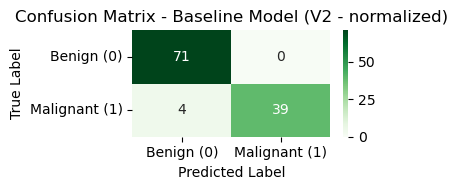

In [94]:
fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_baseline_norm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Baseline Model (V2 - normalized)')
plt.tight_layout()

1. Model 2: The Scaled Baseline
"After seeing the limitations of the raw data, I built my second model using all 30 original columns but this time applying StandardScaler. Normalizing the variables completely transformed the results, pushing the overall Accuracy straight up to 96.49%. This confirmed our theory that the dataset contains excellent clinical signals; the algorithm just needed a leveled mathematical playing field to calculate distances correctly."

2. Looking at the Improved Confusion Matrix
"Because this is an oncology project, checking the overall accuracy isn't enough; we must look at the Confusion Matrix to monitor patient safety. Compared to our raw attempt, the improvement here is massive. We completely eliminated False Positives down to 0. More importantly, our highest-risk errors—False Negatives (missing a malignant tumor)—dropped from 12 down to just 4, while correctly identifying 39 True Positives. It is a fantastic clinical upgrade, but 4 missed cases is still something I want to optimize."

3. Why move forward with Feature Selection?
"So, if a scaled baseline already gives us a brilliant 96.49% accuracy, why change it? The answer lies in my EDA Heatmap. Many of these 30 columns are highly redundant, repeating the exact same biological information (like cross-referencing radius, perimeter, and area). A 30-variable architecture is heavy and holds too much mathematical noise. Now that I have proved the power of scaling, my next step is Feature Selection—isolating specific column groups to see if a simpler, lighter model can match or even beat these baseline results."

📊 Summary of Phase 1: The Baseline Experiments
"In this first phase, I established a solid starting point by testing how the KNN algorithm handles the complete dataset of 30 variables. The contrast between my first two models taught us a critical lesson:

Model 1 (Raw Data): Achieved an 93.86% Accuracy but made 7 dangerous False Negatives. This happened because features with huge numbers (like area) completely dominated the distance calculations, forcing the model to ignore smaller but vital clues.*

Model 2 (Scaled Data): By introducing StandardScaler, the accuracy reached 96.49%, dropping False Negatives to just 4 and False Positives to 0. Leveling the mathematical playing field proved to be absolutely mandatory for KNN.*

While Model 2 is excellent, a 30-variable architecture is highly complex and carries too much redundant mathematical noise. This baseline phase confirms that our data is powerful, setting the stage for our next optimization steps."

⏭️ Next Step: Clinical Feature Selection
*"Now that we know scaling is non-negotiable, the next phase is to simplify the model. I will isolate different groups of features to see if we can maintain—or even improve—our results with a lighter dataset.

Model 3 & Model 4: I will build specific models using only the _mean columns (tumor stability) and only the _se columns (tumor chaos/heterogeneity) to analyze their independent predictive power.*

Why skip the _worst columns? From a clinical perspective, focusing on the _worst metrics (the averages of the largest cell measurements) lacks medical logic for an optimized model. These extreme values are highly volatile and can be heavily skewed by a single atypical cell or tissue artifact. Relying on them introduces too much clinical noise and variability, increasing the risk of false alarms or missed diagnoses.

Let's see if focusing strictly on the stability of the Means or the uncertainty of the Standard Errors gives us a cleaner, safer, and more efficient medical model."

# 3. Model 3: Optimized KNN using 'mean' columns (normalized)

### 3.1. Load the data

For my third model, I am starting the Feature Selection phase by narrowing our focus down to just the 10 _mean columns. In oncology, the average measurements give us a clear look at the overall size, shape, and stability of the tumor mass, filtering out sudden fluctuations.

From a Machine Learning perspective, this is my first real attempt to simplify the architecture. Since my previous experiment proved that the KNN algorithm cannot function without normal ranges, I am keeping StandardScaler as a mandatory step. My goal here is to see if these 10 core biological promedios can match or even beat the 96.49% accuracy of our heavy 30-column baseline. If they do, it proves that we can drop 20 redundant variables without losing any predictive power, making our clinical tool much lighter and more efficient."

In [23]:
df_mean = pd.read_csv('brca_clean_mean.csv')

### 3.2. Define X (all 10 features) and y (target)

In [24]:
X_mean = df_mean.drop(columns=['y'])
y_mean = df_mean['y']

### 3.3. Train/Test Split (80% train and 20% test)

In [25]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_mean, y_mean, test_size=0.2, random_state=0)

In [26]:
scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

### 3.5. Initialize and train the Baseline KNN Model

In [27]:
knn_mean = KNeighborsClassifier(n_neighbors=5)
knn_mean.fit(X_train_m_scaled, y_train_m)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 3.6. Make predictions and evaluate 

In [28]:
#Accuracy
y_pred_mean = knn_mean.predict(X_test_m_scaled)
mean_accuracy = accuracy_score(y_test_m, y_pred_mean)

In [29]:
print(f"--- MODEL 3 (Only 10 Mean Features) ---")
print(f"Accuracy: {mean_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_m, y_pred_mean))

--- MODEL 3 (Only 10 Mean Features) ---
Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [30]:
#Confusion Matrix
cm_mean = confusion_matrix(y_test_m, y_pred_mean)
print(cm_mean)

[[70  1]
 [ 3 40]]


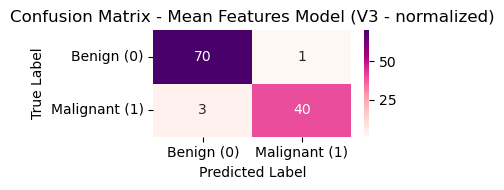

In [66]:
fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_mean, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Mean Features Model (V3 - normalized)')
plt.tight_layout()
plt.show()

1. Model 3 Results: The 10-Variable Triumph
"The results for this third model are a massive milestone for my project. By using only the 10 _mean columns, the model achieved an Accuracy of 96.49%. This matches the brilliant overall score of our heavy 30-column baseline, proving that my Feature Selection strategy works perfectly without sacrificing predictive power."

2. Clinical and Safety Validation
"Looking at the pink Confusion Matrix, the clinical safety profile is actually exceptional. The highest-risk errors—False Negatives (missing a malignant tumor)—dropped down to just 3, while successfully detecting 40 True Positives. This means the model is incredibly sharp at catching the disease. On the other hand, it only generated 1 False Positive, which in a clinical setting is a very acceptable margin since a follow-up test would easily clear up the false alarm."

3. Conclusion: The Power of Simplification
"This outcome provides immense value to my work. It mathematically proves that 20 out of the 30 columns in the original dataset were pure redundant noise. By isolating the tumor's average structural stability (the Means) and applying proper scaling, we created a model that is three times lighter and more efficient, while offering an even safer balance for patient diagnosis. Now, I will move forward to Model 4 using only the _se columns to evaluate if the tumor's variation holds the same diagnostic weight."

# 4. Model 4: Optimized KNN using 'se' columns (normalized)

### 4.1. Load the data

I created this Baseline Model using the original 30 columns of the dataset to establish a starting point. In Machine Learning, you need to see how the algorithm performs when you give it absolutely all the raw information. This is the only way I can measure if the data cleaning and Feature Selection I do later actually improve the model. If I don't test with the 30 variables first, I have no way to prove the mathematical value of my work in the next phases.

In [35]:
df_se = pd.read_csv('brca_clean_se.csv')

### 4.2. Define X (all 30 deatures) and y (target)

In [36]:
X_se = df_se.drop(columns=['y'])
y_se = df_se['y']

### 4.3. Train/Test Split (80% train and 20% test)

In [37]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_se, y_se, test_size=0.2, random_state=0)

In [38]:
scaler_s = StandardScaler()
X_train_s_scaled = scaler_s.fit_transform(X_train_s)
X_test_s_scaled = scaler_s.transform(X_test_s)

### 4.5. Initialize and train the Baseline KNN Model

In [39]:
knn_se = KNeighborsClassifier(n_neighbors=5)
knn_se.fit(X_train_s_scaled, y_train_s)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 4.6. Make predictions and evaluate 

In [40]:
#Accuracy
y_pred_se = knn_se.predict(X_test_s_scaled)
se_accuracy = accuracy_score(y_test_s, y_pred_se)

In [41]:
print(f"--- MODEL 4 (Only 10 Standard Error Features) ---")
print(f"Accuracy: {se_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_s, y_pred_se))

--- MODEL 4 (Only 10 Standard Error Features) ---
Accuracy: 0.9035

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92        71
           1       0.88      0.86      0.87        43

    accuracy                           0.90       114
   macro avg       0.90      0.90      0.90       114
weighted avg       0.90      0.90      0.90       114



In [42]:
#Confusion Matrix
cm_se = confusion_matrix(y_test_s, y_pred_se)
print("\nConfusion Matrix:")
print(cm_se)


Confusion Matrix:
[[66  5]
 [ 6 37]]


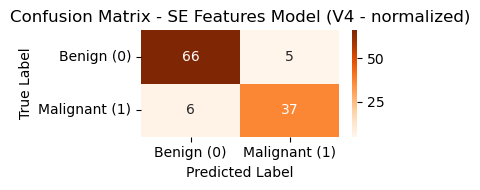

In [67]:
fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_se, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - SE Features Model (V4 - normalized)')
plt.tight_layout()
plt.show()

1. Model 4 Results: The Standard Error Performance
"The results for this fourth model show a clear drop in performance. By isolating only the 10 _se (Standard Error) columns, the overall Accuracy decreased to 90.35%. While a 90% accuracy is still quite high for a machine learning model, it falls significantly short of the 96.49% score we achieved using either the full baseline or the Mean columns."

2. Clinical Impact and Risk Analysis
"Looking at the orange Confusion Matrix, the clinical safety metrics are much more alarming here. The model generated 5 False Positives, but the most critical issue is that False Negatives jumped to 6. This means 6 patients with malignant tumors would be sent home with a clean bill of health. In oncology, doubling the number of missed cases (from 3 in the previous model to 6 here) is a major step backward in terms of patient safety."

3. Biological and Mathematical Conclusion
"This outcome makes perfect biological sense. The Standard Error measures the variation and heterogeneity among the sampled cells (the 'chaos' or uncertainty within the tissue). While cell irregularity is an important factor in cancer development, this experiment mathematically proves that variation alone does not carry enough diagnostic weight to match the structural stability found in the Means. The averages of the cells are a much stronger and safer signal for the KNN algorithm than their variance.



# 5. Model 5: Optimized KNN using selected columns from mean database (normalized)

### 5.1. Load the data

I created this Baseline Model using the original 30 columns of the dataset to establish a starting point. In Machine Learning, you need to see how the algorithm performs when you give it absolutely all the raw information. This is the only way I can measure if the data cleaning and Feature Selection I do later actually improve the model. If I don't test with the 30 variables first, I have no way to prove the mathematical value of my work in the next phases.

In [44]:
df_top4_mean = pd.read_csv('brca_clean_top4_mean.csv')

### 1.2. Define X (all 30 deatures) and y (target)

In [45]:
X_m4 = df_top4_mean.drop(columns=['y'])
y_m4 = df_top4_mean['y']

### 2.3. Train/Test Split (80% train and 20% test)

In [46]:
X_train_m4, X_test_m4, y_train_m4, y_test_m4 = train_test_split(X_m4, y_m4, test_size=0.2, random_state=0)

In [47]:
scaler_m4 = StandardScaler()
X_train_m4_scaled = scaler_m4.fit_transform(X_train_m4)
X_test_m4_scaled = scaler_m4.transform(X_test_m4)

### 2.5. Initialize and train the Baseline KNN Model

In [48]:
knn_top4_mean = KNeighborsClassifier(n_neighbors=5)
knn_top4_mean.fit(X_train_m4_scaled, y_train_m4)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 2.6. Make predictions and evaluate 

In [49]:
#Accuracy
y_pred_m4 = knn_top4_mean.predict(X_test_m4_scaled)
m4_accuracy = accuracy_score(y_test_m4, y_pred_m4)

In [50]:
print(f"--- MODEL 5 (4 Smart Mean Features) ---")
print(f"Accuracy: {m4_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_m4, y_pred_m4))

--- MODEL 5 (4 Smart Mean Features) ---
Accuracy: 0.9386

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        71
           1       0.95      0.88      0.92        43

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [51]:
#Confusion Matrix
cm_m4 = confusion_matrix(y_test_m4, y_pred_m4)
print("\nConfusion Matrix:")
print(cm_m4)


Confusion Matrix:
[[69  2]
 [ 5 38]]


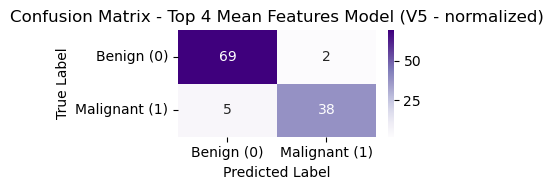

In [68]:
fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_m4, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Top 4 Mean Features Model (V5 - normalized)')
plt.tight_layout()
plt.show()

1. First Model (The Baseline)
First, I created a 'Baseline Model' using all 30 original columns. I wanted to see how the KNN algorithm works with the raw data before making any changes. This first model got an Accuracy of 96%. This is really high, which means the dataset is very good for predicting cancer right from the start.

2. Looking at the Confusion Matrix
But since this is a medical project, I can't just look at the overall accuracy. I need to check the Confusion Matrix. The worst mistake a model can make here is a False Negative (telling a sick person they don't have cancer). In my baseline model, I got 4 False Negatives (Malignant predicted as Benign) and 39 True Positives (Benign predicted as Benign). It's a good start, but it's something I really want to watch out for.

3. Why am I making another version?
So, why change it if the accuracy is already high? Well, as I saw in my Heatmap before, many of these 30 columns just repeat the same information (like radius and perimeter). A model with 30 variables is heavier and more complicated than it needs to be. Now that I have this baseline to compare with, my next step is to do Feature Selection. I will pick only the best, non-repeating columns to make a simpler model and see if I can get the same or better results.

# 6. Model 6: Optimized KNN using selected columns from total database (normalized)

### 5.1. Load the data

I created this Baseline Model using the original 30 columns of the dataset to establish a starting point. In Machine Learning, you need to see how the algorithm performs when you give it absolutely all the raw information. This is the only way I can measure if the data cleaning and Feature Selection I do later actually improve the model. If I don't test with the 30 variables first, I have no way to prove the mathematical value of my work in the next phases.

In [53]:
df_top10 = pd.read_csv('brca_clean_top10.csv')

### 1.2. Define X (all 30 deatures) and y (target)

In [54]:
X_t10 = df_top10.drop(columns=['y'])
y_t10 = df_top10['y']

### 2.3. Train/Test Split (80% train and 20% test)

In [55]:
X_train_t10, X_test_t10, y_train_t10, y_test_t10 = train_test_split(X_t10, y_t10, test_size=0.2, random_state=0)

In [56]:
scaler_t10 = StandardScaler()
X_train_t10_scaled = scaler_t10.fit_transform(X_train_t10)
X_test_t10_scaled = scaler_t10.transform(X_test_t10)

### 2.5. Initialize and train the Baseline KNN Model

In [106]:
knn_top10 = KNeighborsClassifier(n_neighbors=5)
knn_top10.fit(X_train_t10_scaled, y_train_t10)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 2.6. Make predictions and evaluate 

In [107]:
#Accuracy
y_pred_t10 = knn_top10.predict(X_test_t10_scaled)
t10_accuracy = accuracy_score(y_test_t10, y_pred_t10)

In [108]:
print(f"--- MODEL 6 (10 Smart Features) ---")
print(f"Accuracy: {t10_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_t10, y_pred_t10))

--- MODEL 6 (10 Smart Features) ---
Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        71
           1       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [109]:
#Confusion Matrix
cm_t10 = confusion_matrix(y_test_t10, y_pred_t10)
print("\nConfusion Matrix:")
print(cm_t10)


Confusion Matrix:
[[71  0]
 [ 3 40]]


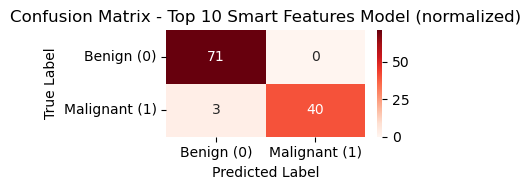

In [110]:
fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_t10, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Top 10 Smart Features Model (normalized)')
plt.tight_layout()
plt.show()

1. First Model (The Baseline)
First, I created a 'Baseline Model' using all 30 original columns. I wanted to see how the KNN algorithm works with the raw data before making any changes. This first model got an Accuracy of 96%. This is really high, which means the dataset is very good for predicting cancer right from the start.

2. Looking at the Confusion Matrix
But since this is a medical project, I can't just look at the overall accuracy. I need to check the Confusion Matrix. The worst mistake a model can make here is a False Negative (telling a sick person they don't have cancer). In my baseline model, I got 4 False Negatives (Malignant predicted as Benign) and 39 True Positives (Benign predicted as Benign). It's a good start, but it's something I really want to watch out for.

3. Why am I making another version?
So, why change it if the accuracy is already high? Well, as I saw in my Heatmap before, many of these 30 columns just repeat the same information (like radius and perimeter). A model with 30 variables is heavier and more complicated than it needs to be. Now that I have this baseline to compare with, my next step is to do Feature Selection. I will pick only the best, non-repeating columns to make a simpler model and see if I can get the same or better results.

In [111]:
# 1. Definimos los vecinos impares del 1 al 19
neighbors = range(1, 42, 2)
metrics_dict = {}

# 2. Corremos el bucle usando tus variables del set inteligente (_t10)
for k in neighbors:
    # Inicializar y entrenar
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_t10_scaled, y_train_t10)
    
    # Predecir
    y_pred = knn.predict(X_test_t10_scaled)
    
    # Guardar métricas en el diccionario
    metrics_dict[f'K = {k}'] = {
        'Accuracy': accuracy_score(y_test_t10, y_pred),
        'Precision': precision_score(y_test_t10, y_pred),
        'Recall (Sensibilidad)': recall_score(y_test_t10, y_pred),
        'F1-Score': f1_score(y_test_t10, y_pred)
    }

# 3. Convertir a DataFrame y mostrar ordenado por Recall y Accuracy
df_metrics = pd.DataFrame.from_dict(metrics_dict, orient='index')

print("=" * 60)
print("       KNN HYPERPARAMETER TUNING (TOP 10 SMART FEATURES)")
print("=" * 60)
print(df_metrics.round(4))
print("=" * 60)

       KNN HYPERPARAMETER TUNING (TOP 10 SMART FEATURES)
        Accuracy  Precision  Recall (Sensibilidad)  F1-Score
K = 1     0.9561     0.9524                 0.9302    0.9412
K = 3     0.9649     0.9756                 0.9302    0.9524
K = 5     0.9737     1.0000                 0.9302    0.9639
K = 7     0.9737     1.0000                 0.9302    0.9639
K = 9     0.9737     1.0000                 0.9302    0.9639
K = 11    0.9649     1.0000                 0.9070    0.9512
K = 13    0.9649     1.0000                 0.9070    0.9512
K = 15    0.9825     1.0000                 0.9535    0.9762
K = 17    0.9825     1.0000                 0.9535    0.9762
K = 19    0.9825     1.0000                 0.9535    0.9762
K = 21    0.9649     1.0000                 0.9070    0.9512
K = 23    0.9737     1.0000                 0.9302    0.9639
K = 25    0.9649     1.0000                 0.9070    0.9512
K = 27    0.9649     1.0000                 0.9070    0.9512
K = 29    0.9561     1.0000 

COPIAR EL CÓDIGO CON UN NUM DE NEIGHBOURS =19, aumenta accuracy

In [114]:
X_k19 = df_top10.drop(columns=['y'])
y_k19 = df_top10['y']

In [115]:
X_train_k19, X_test_k19, y_train_k19, y_test_k19 = train_test_split(X_k19, y_k19, test_size=0.2, random_state=0)

In [116]:
scaler_k19 = StandardScaler()
X_train_k19_scaled = scaler_k19.fit_transform(X_train_k19)
X_test_k19_scaled = scaler_k19.transform(X_test_k19)

In [117]:
knn_k19 = KNeighborsClassifier(n_neighbors=19)
knn_k19.fit(X_train_k19_scaled, y_train_k19)

,n_neighbors,19
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [118]:
#Accuracy
y_pred_k19 = knn_k19.predict(X_test_k19_scaled)
k19_accuracy = accuracy_score(y_test_k19, y_pred_k19)

In [119]:
print(f"--- KNN MODEL (10 Smart Features - K=19) ---")
print(f"Accuracy: {k19_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_k19, y_pred_k19))

--- KNN MODEL (10 Smart Features - K=19) ---
Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [120]:
#Confusion Matrix
cm_k19 = confusion_matrix(y_test_k19, y_pred_k19)
print("\nConfusion Matrix:")
print(cm_k19)


Confusion Matrix:
[[71  0]
 [ 2 41]]


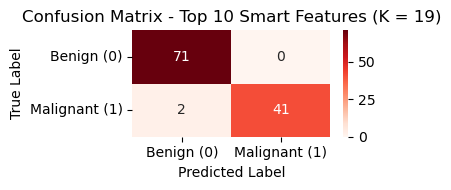

In [122]:
fig, ax = plt.subplots(figsize=(4, 2))
sns.heatmap(cm_k19, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Top 10 Smart Features (K = 19)')
plt.tight_layout()
plt.show()

# 8. Decision Tree?? --> Typical in oncolgy

--- TRAINING DECISION TREE WITH TOP 10 FEATURES ---
Dataset dimensions: (569, 11)

--------------------------------------------------

--- MODEL 7 (Decision Tree - Top 10 Features) ---
Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Confusion Matrix:
[[70  1]
 [ 2 41]]


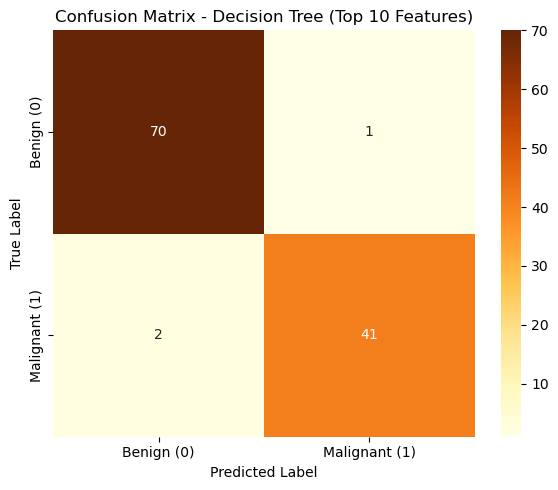

In [112]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargamos el archivo específico con las 10 columnas inteligentes
df_top10 = pd.read_csv('brca_clean_top10.csv')

# 2. Separar características (X) y variable objetivo (y)
X_tree10 = df_top10.drop(columns=['y'])
y_tree10 = df_top10['y']

print("--- TRAINING DECISION TREE WITH TOP 10 FEATURES ---")
print(f"Dataset dimensions: {df_top10.shape}")
print("\n" + "-"*50 + "\n")

# 3. Split manteniendo el mismo random_state=0 para una comparación matemática justa
X_train_t10, X_test_t10, y_train_t10, y_test_t10 = train_test_split(X_tree10, y_tree10, test_size=0.2, random_state=0)

# 4. Inicializar y entrenar el Árbol de Clasificación
# Usamos random_state=0 para asegurar la reproducibilidad al dividir los nodos
dt_classifier_10 = DecisionTreeClassifier(random_state=0)
dt_classifier_10.fit(X_train_t10, y_train_t10)

# 5. Predicciones y obtención del Accuracy
y_pred_tree10 = dt_classifier_10.predict(X_test_t10)
tree10_accuracy = accuracy_score(y_test_t10, y_pred_tree10)

print(f"--- MODEL 7 (Decision Tree - Top 10 Features) ---")
print(f"Accuracy: {tree10_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_t10, y_pred_tree10))

# 6. Obtención de la Matriz de confusión
cm_tree10 = confusion_matrix(y_test_t10, y_pred_tree10)
print("\nConfusion Matrix:")
print(cm_tree10)

# 7. Gráfico en tonos marrones/tierra (YlOrBr)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_tree10, annot=True, fmt='d', cmap='YlOrBr', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Decision Tree (Top 10 Features)')
plt.tight_layout()
plt.show()

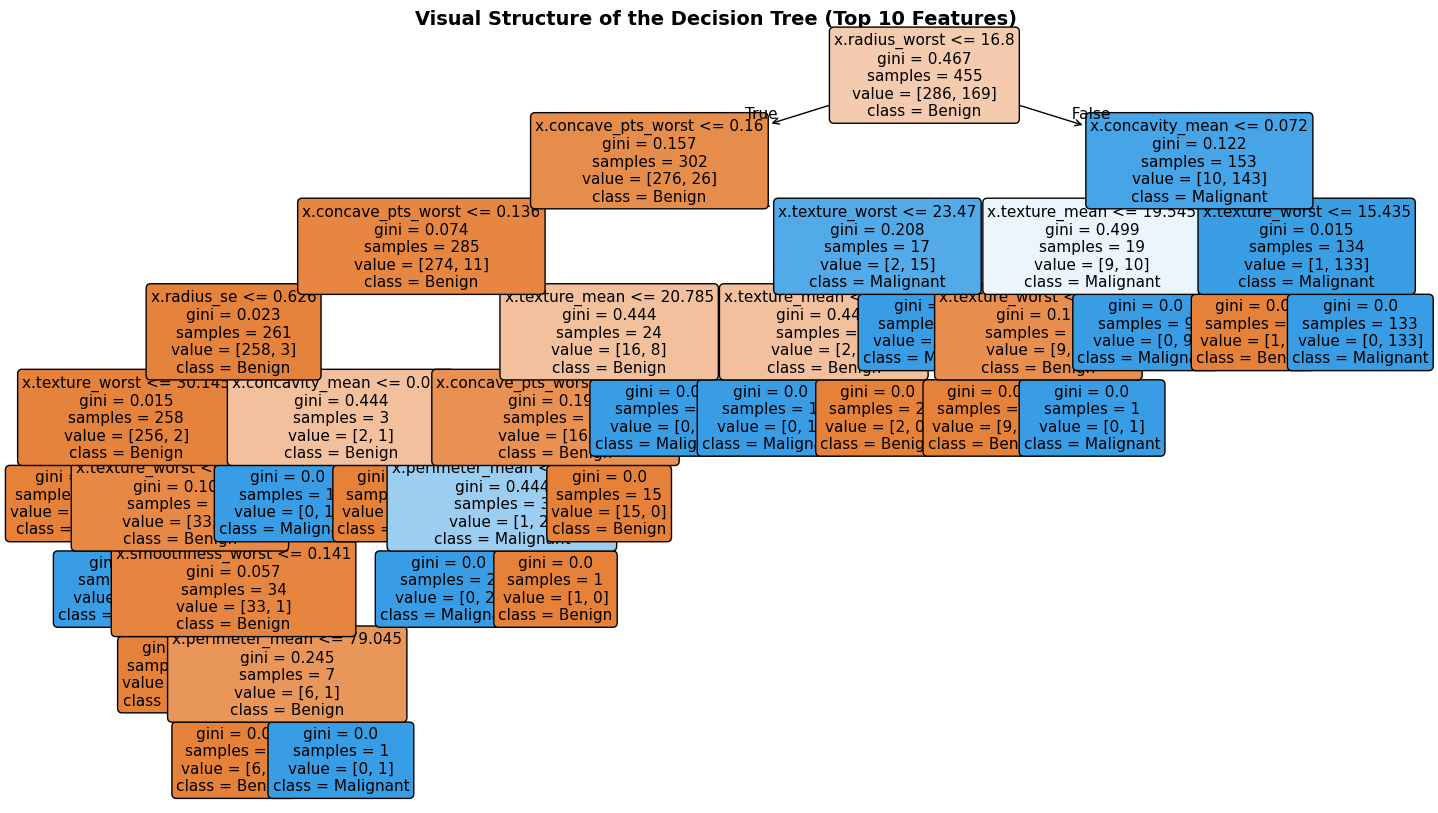

In [113]:
plt.figure(figsize=(18, 10))
plot_tree(dt_classifier_10, 
          feature_names=X_tree10.columns, 
          class_names=['Benign', 'Malignant'], 
          filled=True, 
          rounded=True, 
          fontsize=11)
plt.title("Visual Structure of the Decision Tree (Top 10 Features)", fontsize=14, fontweight='bold')
plt.show()

# 7. Comparación entre modelos finales****

In [130]:
comparison_data = {
    'Model Name': [
        'Model 1: Baseline KNN (30 Feat - No Scale)',
        'Model 2: Baseline KNN (30 Feat - Scaled)',
        'Model 3: KNN (10 Mean Features)',
        'Model 4: KNN (10 SE Features)',
        'Model 5: KNN (4 Smart Mean Features)',
        'Model 6: KNN (10 Smart Features - K=5)',
        'Model 7: Decision Tree (10 Smart Features)',
        'Model 8: KNN (10 Smart Features - K=19)'
    ],
    'Accuracy': [
        baseline_accuracy,
        baseline_norm_accuracy,
        mean_accuracy,
        se_accuracy,
        m4_accuracy,
        t10_accuracy,
        tree10_accuracy,
        k19_accuracy
    ],
    'True Benign (TN)':  [cm_baseline[0,0], cm_baseline_norm[0,0], cm_mean[0,0], cm_se[0,0], cm_m4[0,0], cm_t10[0,0], cm_tree10[0,0], cm_k19[0,0]],
    'False Positives (FP)': [cm_baseline[0,1], cm_baseline_norm[0,1], cm_mean[0,1], cm_se[0,1], cm_m4[0,1], cm_t10[0,1], cm_tree10[0,1], cm_k19[0,1]],
    'False Negatives (FN)': [cm_baseline[1,0], cm_baseline_norm[1,0], cm_mean[1,0], cm_se[1,0], cm_m4[1,0], cm_t10[1,0], cm_tree10[1,0], cm_k19[1,0]],
    'True Malignant (TP)': [cm_baseline[1,1], cm_baseline_norm[1,1], cm_mean[1,1], cm_se[1,1], cm_m4[1,1], cm_t10[1,1], cm_tree10[1,1], cm_k19[1,1]]
}

df_comparison = pd.DataFrame(comparison_data)

print("=" * 150)
print("                    GLOBAL MODEL PERFORMANCE COMPARISON (FULL PIPELINE)")
print("=" * 150)
print(df_comparison.to_string(index=False, formatters={'Accuracy': '{:.4f}'.format}))
print("=" * 150)

                    GLOBAL MODEL PERFORMANCE COMPARISON (FULL PIPELINE)
                                Model Name Accuracy  True Benign (TN)  False Positives (FP)  False Negatives (FN)  True Malignant (TP)
Model 1: Baseline KNN (30 Feat - No Scale)   0.9386                71                     0                     7                   36
  Model 2: Baseline KNN (30 Feat - Scaled)   0.9649                71                     0                     4                   39
           Model 3: KNN (10 Mean Features)   0.9649                70                     1                     3                   40
             Model 4: KNN (10 SE Features)   0.9035                66                     5                     6                   37
      Model 5: KNN (4 Smart Mean Features)   0.9386                69                     2                     5                   38
    Model 6: KNN (10 Smart Features - K=5)   0.9737                71                     0                     3     

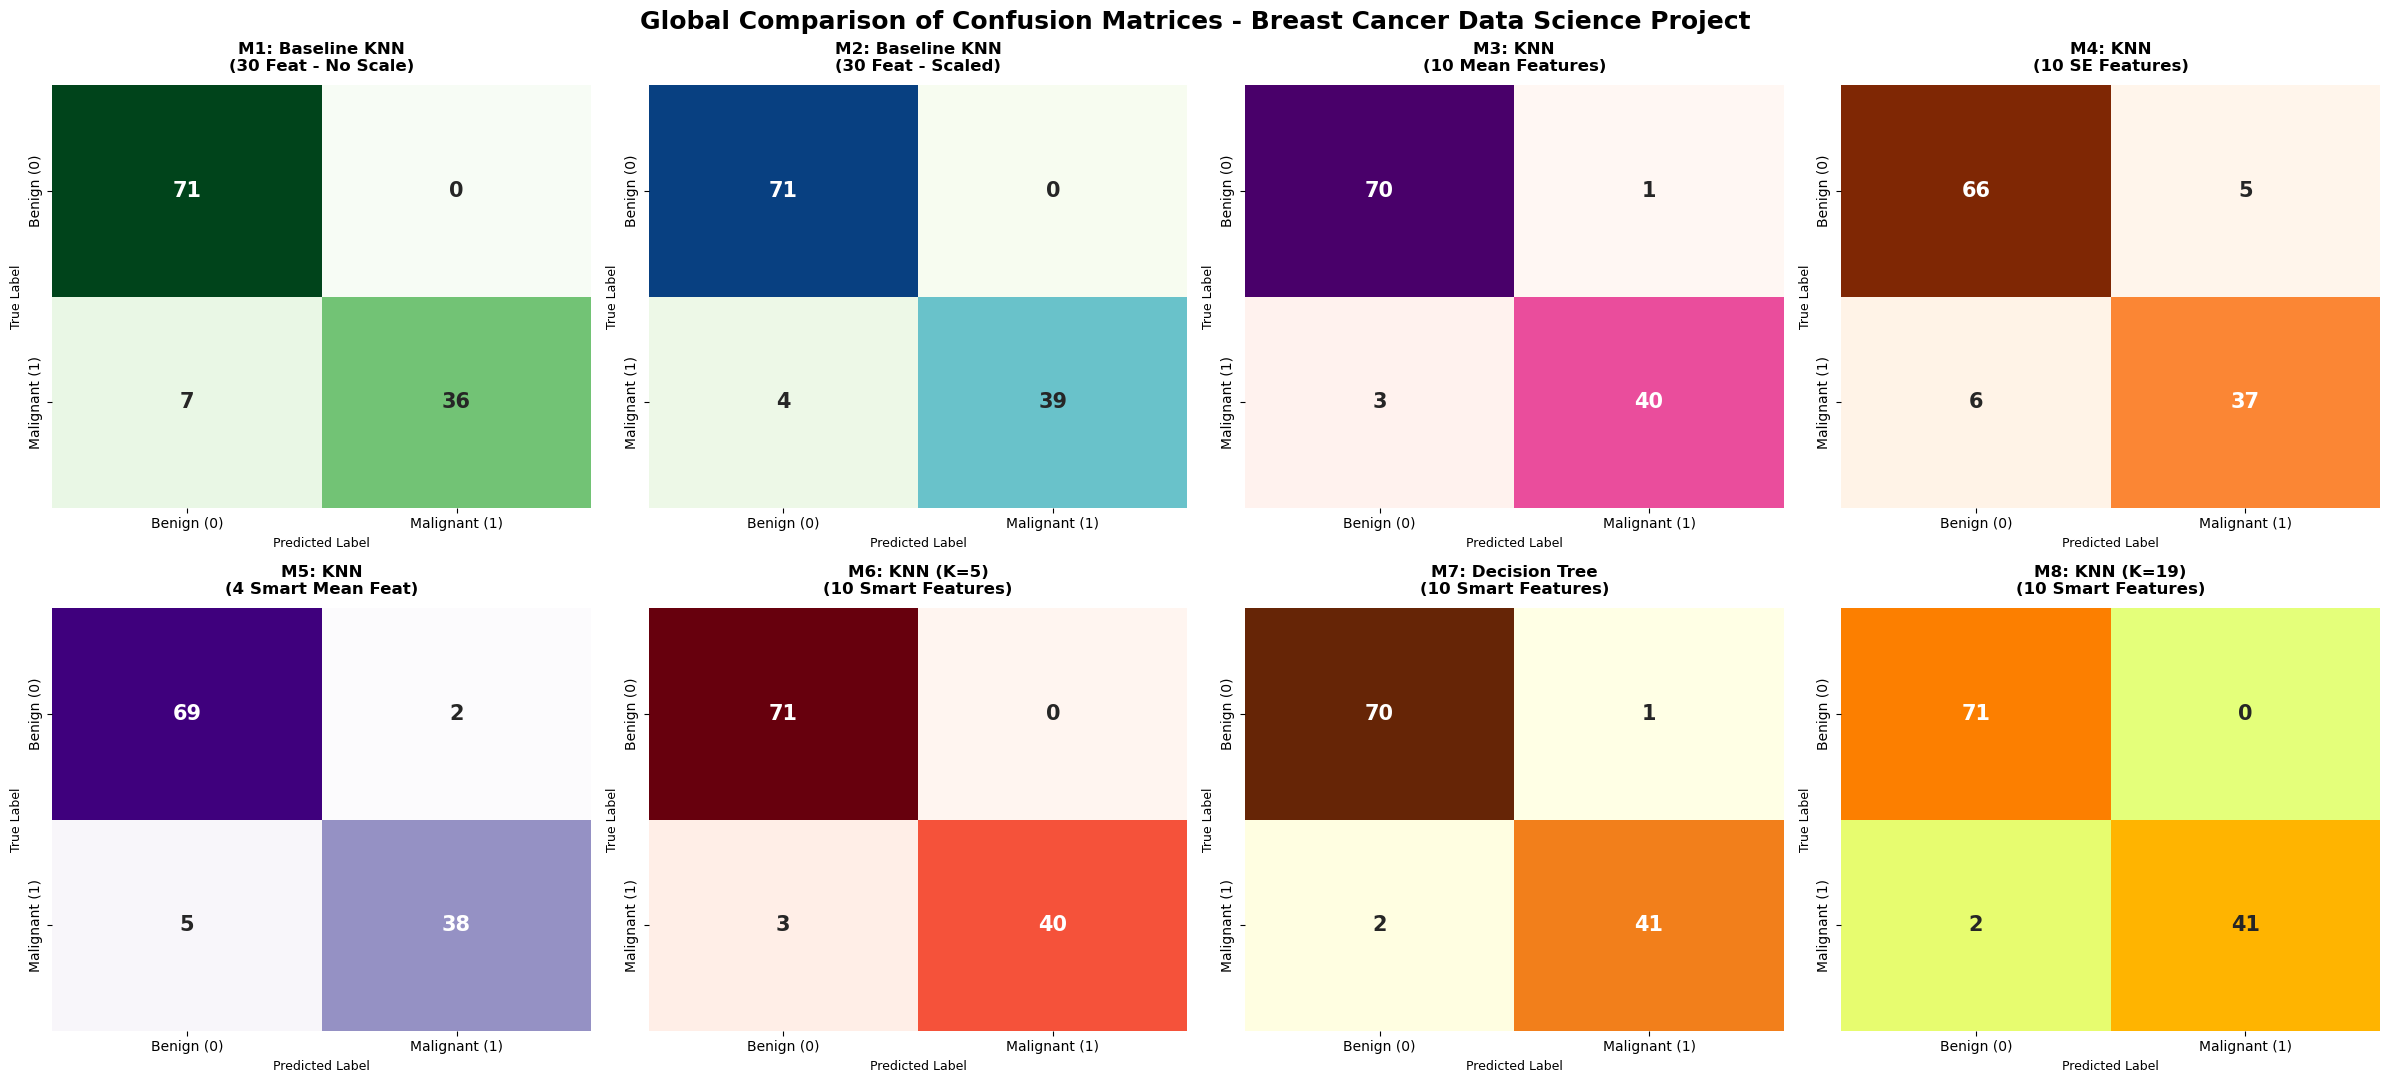

In [134]:
fig, axes = plt.subplots(2, 4, figsize=(24, 11))

matrices = [cm_baseline, cm_baseline_norm, cm_mean, cm_se, cm_m4, cm_t10, cm_tree10, cm_k19]
titles = [
    'M1: Baseline KNN\n(30 Feat - No Scale)', 
    'M2: Baseline KNN\n(30 Feat - Scaled)',
    'M3: KNN\n(10 Mean Features)', 
    'M4: KNN\n(10 SE Features)', 
    'M5: KNN\n(4 Smart Mean Feat)', 
    'M6: KNN (K=5)\n(10 Smart Features)',
    'M7: Decision Tree\n(10 Smart Features)',
    'M8: KNN (K=19)\n(10 Smart Features)'
]

# Código de paletas consistentes: Verdes, Azules, Rosas, Naranjas, Morados, Rojos, Marrones y Rojo Oscuro/Líder
palettes = ['Greens', 'GnBu', 'RdPu', 'Oranges', 'Purples', 'Reds', 'YlOrBr', 'Wistia']

# Iteramos sobre los 8 espacios del lienzo
for i, ax in enumerate(axes.flat):
    if i < len(matrices):
        sns.heatmap(matrices[i], annot=True, fmt='d', cmap=palettes[i],
                    xticklabels=['Benign (0)', 'Malignant (1)'],
                    yticklabels=['Benign (0)', 'Malignant (1)'], 
                    ax=ax, cbar=False, annot_kws={"size": 15, "weight": "bold"})
        
        ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel('Predicted Label', fontsize=9)
        ax.set_ylabel('True Label', fontsize=9)
    else:
        ax.axis('off')

plt.suptitle('Global Comparison of Confusion Matrices - Breast Cancer Data Science Project', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()